In [1]:
from src.model import FNN

import torch
import numpy as np
from scipy.ndimage import uniform_filter1d

# %% Setup
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="ticks", context="notebook")

In [4]:
def load_model(path, device="cpu"):
    checkpoint = torch.load(path, map_location=device)
    model = FNN(checkpoint["p"], hidden=checkpoint["hidden"]).to(device)
    model.load_state_dict(checkpoint["model_state_dict"])
    
    return model, checkpoint, checkpoint["p"]

In [5]:
model, ckpt, p = load_model("results/p71_wd0_seed3/model_final.pt", device="cuda")
model.eval()

/tmp/ipykernel_3102571/2922662048.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path, map_location=device)


FNN(
  (FN): Sequential(
    (0): Linear(in_features=142, out_features=142, bias=False)
    (1): Square()
    (2): Linear(in_features=142, out_features=71, bias=False)
  )
)

In [6]:
# %% Sort neurons by dominant frequency
fc1_weight = model.FN[0].weight.detach()
W_a = fc1_weight[:, :p]

fft = torch.fft.rfft(W_a, dim=1)
power = fft.abs() ** 2
dominant_freq = power.argmax(dim=1)

order = torch.argsort(dominant_freq)
sorted_freq = dominant_freq[order]
fc1_sorted = fc1_weight[order]

print(f"neurons: {len(order)}, frequency range: "
      f"{sorted_freq.min().item()}-{sorted_freq.max().item()}")

fc1_weight = fc1_weight.cpu().numpy()
fc1_sorted = fc1_sorted.cpu().numpy()
sorted_freq = sorted_freq.cpu().numpy()

neurons: 142, frequency range: 1-35


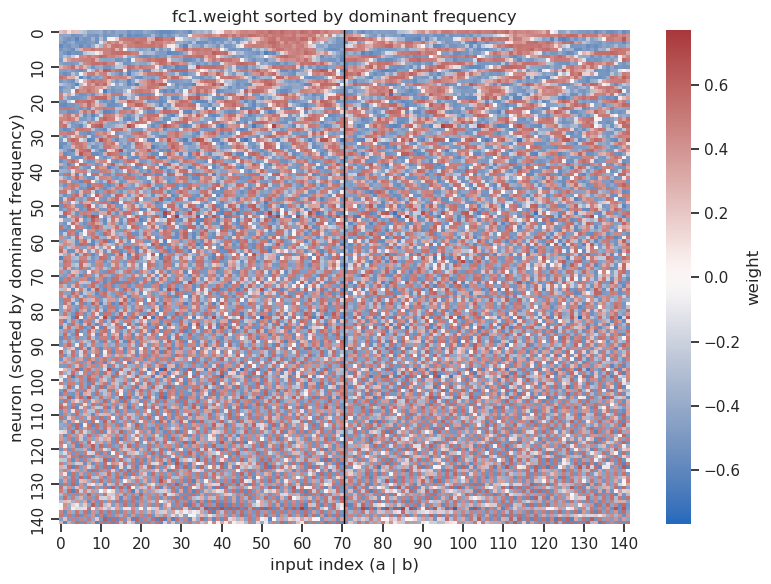

In [7]:
# %% Heatmap of sorted fc1.weight
lim = np.abs(fc1_sorted).max()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(fc1_sorted, ax=ax, cmap="vlag", center=0, vmin=-lim, vmax=lim,
            xticklabels=10, yticklabels=10, rasterized=True,
            cbar_kws={"label": "weight"})
ax.axvline(p, color="black", linewidth=1)
ax.set_xlabel("input index (a | b)")
ax.set_ylabel("neuron (sorted by dominant frequency)")
ax.set_title("fc1.weight sorted by dominant frequency")
plt.tight_layout()
plt.show()

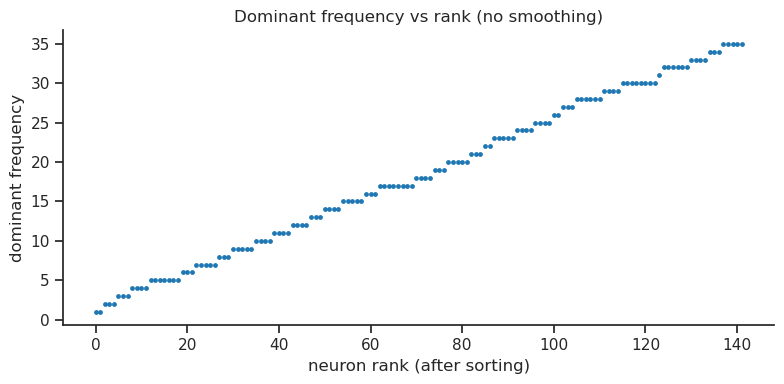

In [10]:
# %% Dominant frequency vs neuron rank
fig, ax = plt.subplots(figsize=(8, 4))
sns.scatterplot(x=np.arange(len(sorted_freq)), y=sorted_freq, ax=ax,
                s=12, linewidth=0, color="tab:blue")
ax.set_xlabel("neuron rank (after sorting)")
ax.set_ylabel("dominant frequency")
ax.set_title("Dominant frequency vs rank (no smoothing)")
sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

def to_one_hot(batch_input, p):
    a_oh = F.one_hot(batch_input[:, 0], num_classes=p).float()
    b_oh = F.one_hot(batch_input[:, 1], num_classes=p).float()
    return torch.cat([a_oh, b_oh], dim=1)

In [ ]:
def logit_sum_structure(model, p, device="cpu"):
    a = torch.arange(p).repeat_interleave(p)
    b = torch.arange(p).repeat(p)
    x = to_one_hot(torch.stack([a, b], 1), p).to(device)
    with torch.no_grad():
        L = model(x).cpu().numpy()                      
    L = L - L.mean()
    s = ((a[:, None] + b[:, None] - torch.arange(p)[None, :]) % p).numpy()
    means = np.array([L[s == r].mean() for r in range(p)])
    explained = (means[s] ** 2).sum() / (L ** 2).sum()
    return explained

print(logit_sum_structure(model, p=p, device="cuda"))

0.56206965


In [ ]:
def logit_decomposition(model, p):
    device = next(model.parameters()).device
    a = torch.arange(p).repeat_interleave(p)
    b = torch.arange(p).repeat(p)
    x = to_one_hot(torch.stack([a, b], 1), p).to(device)
    with torch.no_grad():
        L = model(x).cpu().numpy()                     # (p², p)
    L = L - L.mean(axis=1, keepdims=True)           
    total = (L ** 2).sum()

    A, B = a.numpy()[:, None], b.numpy()[:, None]
    Q = np.arange(p)[None, :]
    terms = {
        "a+b-q": (A + B - Q), "a+b+q": (A + B + Q),
        "a-b-q": (A - B - Q), "a-b+q": (A - B + Q),
        "2a-q": (2 * A - Q),  "2a+q": (2 * A + Q),
        "2b-q": (2 * B - Q),  "2b+q": (2 * B + Q),
        "q": np.broadcast_to(Q, L.shape),
    }
    out = {}
    for name, s in terms.items():
        s = s % p
        means = np.array([L[s == r].mean() for r in range(p)])
        out[name] = float((means[s] ** 2).sum() / total)
    out["reszta"] = 1 - sum(out.values())
    return out

logit_decomposition(model, p=71)

{'a+b-q': 0.5624461770057678,
 'a+b+q': 0.069325752556324,
 'a-b-q': 0.05292651057243347,
 'a-b+q': 0.06774187088012695,
 '2a-q': 0.002891448326408863,
 '2a+q': 0.0038296296261250973,
 '2b-q': 0.0030836225487291813,
 '2b+q': 0.002906010253354907,
 'q': 0.004920996725559235,
 'reszta': 0.22992798150517046}

neurony ze wspólną częstotliwością a, b, q: 142/142


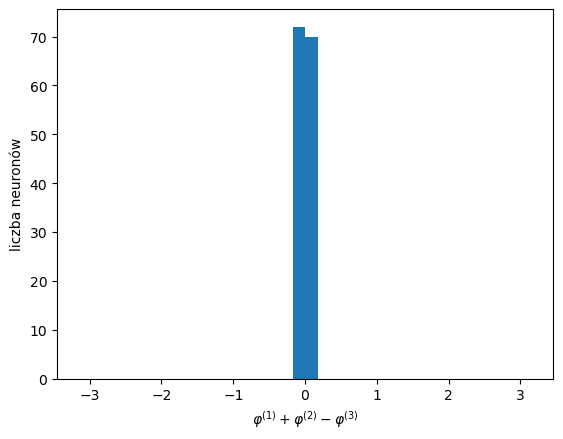

(array([ 0.03770006,  0.04680521, -0.02601792,  0.04361486, -0.04569316,
       -0.0654434 , -0.0124315 , -0.01382798, -0.10173732,  0.02371008,
       -0.00010586, -0.01280415,  0.02093911,  0.01761234, -0.03730428,
       -0.02059674, -0.06034357, -0.01435393, -0.00226671, -0.05057657,
       -0.0765121 ,  0.02465088, -0.00066597,  0.0042634 , -0.03273226,
       -0.01957542, -0.04515242, -0.04723907,  0.02008932, -0.00026488,
       -0.02892423, -0.00235295,  0.04476309, -0.04015636,  0.00132263,
       -0.00982267, -0.00636351, -0.02288103,  0.03019452, -0.00709532,
        0.06247354, -0.00922942,  0.00958276,  0.00874645,  0.0108037 ,
        0.00770593,  0.01455986,  0.04445004, -0.01155901, -0.06405759,
        0.06864326, -0.00141773,  0.03819639, -0.03134752, -0.05637199,
       -0.03058941,  0.04000974,  0.07007217, -0.03744477,  0.07289195,
        0.02925331, -0.0524416 , -0.05607628, -0.03519804, -0.00231624,
       -0.03820825,  0.01943624,  0.04416347,  0.0556736 , -0.0

In [ ]:
def gromov_phases(model, p):
    W1 = model.FN[0].weight.detach().cpu().numpy()      # (N, 2p)
    W2 = model.FN[2].weight.detach().cpu().numpy()      # (p, N)
    Fa = np.fft.fft(W1[:, :p], axis=1)
    Fb = np.fft.fft(W1[:, p:], axis=1)
    Fq = np.fft.fft(W2.T, axis=1)                     

    half = (p - 1) // 2
    ma = np.abs(Fa[:, 1:half + 1]).argmax(1) + 1
    mb = np.abs(Fb[:, 1:half + 1]).argmax(1) + 1
    mq = np.abs(Fq[:, 1:half + 1]).argmax(1) + 1
    same = (ma == mb) & (mb == mq)

    k = np.arange(len(ma))
    phi1, phi2, phi3 = (np.angle(F[k, ma]) for F in (Fa, Fb, Fq))
    delta = np.angle(np.exp(1j * (phi1 + phi2 - phi3)))  # (-π, π]

    print(f"neurony ze wspólną częstotliwością a, b, q: {same.sum()}/{len(same)}")
    plt.hist(delta[same], bins=36, range=(-np.pi, np.pi))
    plt.xlabel(r"$\varphi^{(1)}+\varphi^{(2)}-\varphi^{(3)}$")
    plt.ylabel("liczba neuronów")
    plt.show()
    return delta, same

print(gromov_phases(model=model, p=p))